# **A Simple Knowledge Distilation Project**
#### Sample: Teacher & Student, both CNN
####  By Shayan Rokhva

# **Google Drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# **GPU**

jupyter notebook --NotebookApp.allow_origin='https://colab.research.google.com' --port=4000 --NotebookApp.port_retries=0

In [ ]:
!nvidia-smi

Fri Oct  7 07:54:26 2022       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 512.15       Driver Version: 512.15       CUDA Version: 11.6     |
|-------------------------------+----------------------+----------------------+
| GPU  Name            TCC/WDDM | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  NVIDIA GeForce ... WDDM  | 00000000:01:00.0  On |                  N/A |
| 25%   33C    P8    25W / 215W |    355MiB /  8192MiB |      3%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
                                                                               
+-------

# **Install**

In [ ]:
!pip install torchmetrics

# **Imports 📢**

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader, random_split
import torch.backends.cudnn as cudnn

import torchvision
from torchvision.datasets import CIFAR10
from torchvision import transforms as T

from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

from torchmetrics import Accuracy
from tqdm import tqdm

# **Init**

In [ ]:
num_cls = 10

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# **Utils 🧰**

In [ ]:
# AverageMeter for averaging

class AverageMeter(object):
    """Computes and stores the average and current value"""
    def __init__(self):
        self.reset()

    def reset(self):
        self.val = 0
        self.avg = 0
        self.sum = 0
        self.count = 0

    def update(self, val, n=1):
        self.val = val
        self.sum += val * n
        self.count += n
        self.avg = self.sum / self.count

In [ ]:
# Coutning Parameters

def num_params(model):
  nums = sum(p.numel() for p in model.parameters())/1e6
  return nums

In [ ]:
# Normalizing and Plotting

def normalize_image(image):
  image_min = image.min()
  image_max = image.max()
  image.clamp_(min = image_min, max = image_max)
  image.add_(-image_min).div_(image_max - image_min + 1e-5)
  return image

def plot_images(images, labels, classes, normalize=True):
  n_images = len(images)

  rows = int(np.sqrt(n_images))
  cols = int(np.sqrt(n_images))

  fig = plt.figure(figsize=(10, 10))

  for i in range(rows*cols):

    ax = fig.add_subplot(rows, cols, i+1)
    
    image = images[i]
    if normalize:
      image = normalize_image(image)

    ax.imshow(image.permute(1, 2, 0).cpu().numpy())
    ax.set_title(classes[labels[i]])
    ax.axis('off')

# **Dataset 🗂️**

## Transform

In [ ]:
transform_train = T.Compose([T.RandomCrop(32, padding=4),
                             T.RandomHorizontalFlip(),
                             T.ToTensor(),
                             T.Normalize(mean=(0.4914, 0.4822, 0.4465), 
                                         std=(0.2023, 0.1994, 0.2010))])  # Mean & STD from ImageNet

transform_test = T.Compose([T.ToTensor(),
                            T.Normalize(mean=(0.4914, 0.4822, 0.4465), 
                                        std=(0.2023, 0.1994, 0.2010))])

## CIFAR Dataset

In [ ]:
# We use CIFAR since it is bulit-in in PyTorch and convenient

In [ ]:
train_set = CIFAR10(root='./deep-learning-2022-howsam/cifar10', train=True, 
                    download=True, 
                    transform=transform_train)

test_set = CIFAR10(root='./deep-learning-2022-howsam/cifar10', train=False, 
                   download=True,
                   transform=transform_test)

Files already downloaded and verified
Files already downloaded and verified


In [ ]:
train_set.data.shape

(50000, 32, 32, 3)

## DataLoader

In [ ]:
train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
test_loader = DataLoader(test_set, batch_size=128, shuffle=False)

In [ ]:
x, y = next(iter(train_loader))
print(x.shape)
print(y)

torch.Size([64, 3, 32, 32])
tensor([6, 7, 3, 4, 1, 4, 9, 2, 1, 0, 6, 7, 3, 8, 8, 8, 6, 7, 6, 3, 5, 0, 4, 2,
        4, 9, 0, 5, 5, 8, 1, 6, 2, 7, 8, 1, 0, 0, 2, 8, 6, 1, 2, 3, 3, 1, 4, 2,
        9, 8, 0, 1, 8, 3, 2, 2, 6, 2, 4, 0, 8, 7, 1, 7])


## Visualize

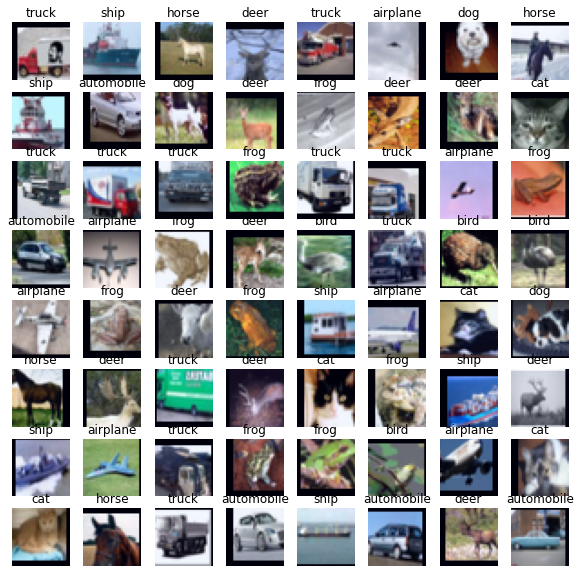

In [ ]:
batch = next(iter(train_loader))
classes = train_set.classes
plot_images(batch[0], batch[1], classes)

# **Model 🧠**

In [ ]:
# Both the teacher and students are Customzied CNN (VGG-like) consisting of Conv, BN, and AF
# Yet, teacher is sligthly more complicated with more Convolutional Blocks and Parameters
# Student is simpler with less feature extraction and parameters (almost a third)
# In here, we train both!!! :)))
# Teacher will be used later in the freezing format with NO updating gradient for teaching the student
# We should not train student now! It should learn from the teacher. However, in here, seperately, ...
# we train it just to have some benchmark for accuracy and performance so that we can compare it with later performance

In [ ]:
# Conv Block
def conv3x3_bn_af(in_channels, out_channels):
  module = nn.Sequential(nn.Conv2d(in_channels, out_channels, 3, padding=1),
                         nn.BatchNorm2d(out_channels),
                         nn.ReLU())
  return module

In [ ]:
# Teacher, slightly more complex, with greater parameters

In [ ]:
def Teacher():
  network = nn.Sequential(conv3x3_bn_af(3, 64),
                          conv3x3_bn_af(64, 64),
                          nn.MaxPool2d(2, 2), # 16x16

                          conv3x3_bn_af(64, 128),
                          conv3x3_bn_af(128, 128),
                          nn.MaxPool2d(2, 2), # 8x8

                          conv3x3_bn_af(128, 256),
                          conv3x3_bn_af(256, 256),
                          nn.MaxPool2d(2, 2), # 4x4

                          conv3x3_bn_af(256, 512),
                          conv3x3_bn_af(512, 512),
                          nn.AdaptiveAvgPool2d(output_size=(1, 1)), # 1x1

                          nn.Flatten(),
                          nn.Linear(512, 10) # classifier
                      )

  return network

In [ ]:
# Student, the same CNN architecture, less complex, less parameters (~35%)

In [ ]:
def Student():
  network = nn.Sequential(conv3x3_bn_af(3, 64),
                          nn.MaxPool2d(2, 2), # 16x16

                          conv3x3_bn_af(64, 128),
                          nn.MaxPool2d(2, 2), # 8x8

                          conv3x3_bn_af(128, 256),
                          nn.MaxPool2d(2, 2), # 4x4

                          conv3x3_bn_af(256, 512),
                          nn.AdaptiveAvgPool2d(output_size=(1, 1)), # 1x1

                          nn.Flatten(),
                          nn.Linear(512, 10) # classifier
                      )

  return network

In [ ]:
# both Teacher & Student should go to device

In [ ]:
teacher = Teacher().to(device)
num_params(teacher)

4.694346

In [ ]:
student = Student().to(device)
num_params(student)

1.558026

# **Functions** 🧮

In [ ]:
# Train one epcoh is for normal training (training the teacher, for instance)
# As can bee seen, there is no teacher and student in inputs. So, this is not for distialtion

def train_one_epoch(model, train_loader, loss_fn, optimizer, epoch=None):
  model.train()
  loss_train = AverageMeter()
  acc_train = Accuracy().to(device)
  with tqdm(train_loader, unit="batch") as tepoch:
    for inputs, targets in tepoch:
      if epoch is not None:
        tepoch.set_description(f"Epoch {epoch}")
      inputs = inputs.to(device)
      targets = targets.to(device)

      outputs = model(inputs)
      
      loss = loss_fn(outputs, targets)

      loss.backward()

      optimizer.step()
      optimizer.zero_grad()

      loss_train.update(loss.item())
      acc_train(outputs, targets.int())
      tepoch.set_postfix(loss=loss_train.avg, 
                         accuracy=100.*acc_train.compute().item())
  return model, loss_train.avg, acc_train.compute().item()

In [ ]:
# Validation
# IMPORTANT: NO GRAD


def validation(model, test_loader, loss_fn):
  model.eval()
  with torch.no_grad():
    loss_valid = AverageMeter()
    acc_valid = Accuracy().to(device)
    for i, (inputs, targets) in enumerate(test_loader):
      inputs = inputs.to(device)
      targets = targets.to(device)

      outputs = model(inputs)
      loss = loss_fn(outputs, targets)
      
      loss_valid.update(loss.item())
      acc_valid(outputs, targets.int())
  return loss_valid.avg, acc_valid.compute().item()

In [ ]:
# This function is used for the knowledge distilation part (student and teacher in inputs)

def train_one_epoch_kd(student, teacher, train_loader, loss_fn, optimizer, epoch=None):
  student.train()
  loss_train = AverageMeter()
  acc_train = Accuracy().to(device)
  with tqdm(train_loader, unit="batch") as tepoch:
    for inputs, targets in tepoch:
      if epoch is not None:
        tepoch.set_description(f"Epoch {epoch}")
      # To device
      inputs = inputs.to(device)
      targets = targets.to(device)

      outputs = student(inputs)
      with torch.no_grad():                           # IMPORTANT: teacher must not go through updating gradient
        teacher_outputs = teacher(inputs)             # IMPORTANT: teacher must not go through updating gradient
      
      loss = loss_fn(outputs, targets, teacher_outputs, T=10, alpha=0.6)
                                                                          # Temperature = 10
                                                                          # alpha = 0.6      
                                                                          # They are not tuned. Experimental

      loss.backward()

      optimizer.step()
      optimizer.zero_grad()

      loss_train.update(loss.item())
      acc_train(outputs, targets.int())
      tepoch.set_postfix(loss=loss_train.avg, 
                         accuracy=100.*acc_train.compute().item())
  return student, loss_train.avg, acc_train.compute().item()              # Only student

# **Train Teacher & Student Models 🔨**

## Step 1: check forward path

Calculate loss for one batch

In [ ]:
model = Teacher().to(device)
loss_fn = nn.CrossEntropyLoss()

x_batch, y_batch = next(iter(train_loader))
outputs = model(x_batch.to(device))
loss = loss_fn(outputs, y_batch.to(device))
print(loss)

tensor(2.3520, device='cuda:0', grad_fn=<NllLossBackward0>)


## Step 2: check backward path

Select 5 random batches and train the model

In [ ]:
_, mini_train_dataset = random_split(train_set, (len(train_set)-500, 500))
mini_train_loader = DataLoader(mini_train_dataset, 20)

In [ ]:
model = Teacher().to(device)
loss_fn = nn.CrossEntropyLoss()

In [ ]:
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

In [ ]:
num_epochs = 100
for epoch in range(num_epochs):
  model, _, _ = train_one_epoch(model, mini_train_loader, loss_fn, optimizer, epoch)

## Step 3: select best lr

Train all data for one epoch

In [ ]:
num_epochs = 3
for lr in [0.9, 0.5, 0.2, 0.1, 0.01, 0.001, 0.0001]:
  print(f'LR={lr}')
  model = Teacher().to(device)
  # model = torch.load('model.pt')
  optimizer = optim.SGD(model.parameters(), lr=lr, weight_decay=1e-4, momentum=0.9)
  for epoch in range(num_epochs):
    model, _, _ = train_one_epoch(model, train_loader, loss_fn, optimizer, epoch)
  print()

LR=0.9


Epoch 2: 100%|██████████████████████████████████████████| 782/782 [00:40<00:00, 19.19batch/s, accuracy=44.8, loss=1.48]



LR=0.5


Epoch 2: 100%|███████████████████████████████████████████| 782/782 [00:40<00:00, 19.32batch/s, accuracy=52.8, loss=1.3]



LR=0.2


...

Epoch 2: 100%|███████████████████████████████████████████| 782/782 [00:40<00:00, 19.21batch/s, accuracy=78, loss=0.635]



LR=0.001


Epoch 2: 100%|█████████████████████████████████████████| 782/782 [00:40<00:00, 19.31batch/s, accuracy=72.6, loss=0.782]



LR=0.0001


Epoch 2: 100%|██████████████████████████████████████████| 782/782 [00:41<00:00, 19.06batch/s, accuracy=49.3, loss=1.41]

In [ ]:
# LR = 0.01 => Found the best

## Step 4: small grid (optional)

Create a small grid based on the WD and the best LR



In [ ]:
# I put this part. Yet, I skip it since this is somewhat educational

In [ ]:
num_epochs = 5

for lr in [0.05, 0.04, 0.03, 0.02, 0.01, 0.009, 0.008, 0.007, 0.006, 0.005]:
  for wd in [1e-4, 1e-5, 0.]:
    model = Teacher().to(device)   
    optimizer = optim.SGD(model.parameters(), lr=lr, weight_decay=wd)
    print(f'LR={lr}, WD={wd}')

    for epoch in range(num_epochs):
      model, loss, _ = train_one_epoch(model, train_loader, loss_fn, optimizer, epoch)
    print()

## Step 5: train more epochs

In [ ]:
# model = Teacher().to(device)
model = Student().to(device)

In [ ]:
lr = 0.01     # found the best
wd = 1e-4     # Avoiding Overfitting

optimizer = optim.SGD(model.parameters(), lr=lr, weight_decay=wd, momentum=0.9)

In [ ]:
loss_train_hist = []
loss_valid_hist = []

acc_train_hist = []
acc_valid_hist = []

best_loss_valid = torch.inf
epoch_counter = 0

In [ ]:
num_epochs = 15

for epoch in range(num_epochs):
  # Train
  model, loss_train, acc_train = train_one_epoch(model, 
                                                 train_loader, 
                                                 loss_fn, 
                                                 optimizer,
                                                 epoch)
  # Validation
  loss_valid, acc_valid = validation(model,
                                     test_loader,
                                     loss_fn)
  
  loss_train_hist.append(loss_train)
  loss_valid_hist.append(loss_valid)

  acc_train_hist.append(acc_train)
  acc_valid_hist.append(acc_valid)
  
  if loss_valid < best_loss_valid:
    torch.save(model, f'student.pt')
    best_loss_valid = loss_valid
    print('Model Saved!')

  print(f'Valid: Loss = {loss_valid:.4}, Acc = {acc_valid:.4}')
  print()

  epoch_counter += 1

Epoch 0: 100%|██████████████████████████████████████████| 782/782 [00:32<00:00, 23.72batch/s, accuracy=50.9, loss=1.34]


Model Saved!
Valid: Loss = 1.24, Acc = 0.5778



Epoch 1: 100%|█████████████████████████████████████████| 782/782 [00:32<00:00, 24.24batch/s, accuracy=65.3, loss=0.975]


Model Saved!
Valid: Loss = 1.185, Acc = 0.6177



Epoch 2: 100%|█████████████████████████████████████████| 782/782 [00:35<00:00, 21.77batch/s, accuracy=70.9, loss=0.828]


...

Valid: Loss = 0.5778, Acc = 0.8104



Epoch 13: 100%|████████████████████████████████████████| 782/782 [00:36<00:00, 21.18batch/s, accuracy=85.2, loss=0.427]


Model Saved!
Valid: Loss = 0.5417, Acc = 0.8201



Epoch 14: 100%|█████████████████████████████████████████| 782/782 [00:35<00:00, 21.73batch/s, accuracy=85.9, loss=0.41]


Model Saved!
Valid: Loss = 0.5039, Acc = 0.8301



In [ ]:
### Attention: As can be seen, the most is still underfit! Yet, due to computational constrain, I say 15 epochs is OK.
### 15 is good since it is for educational purpose

# **Train Knowledge Distillation 👨**

## Knowledge distillation loss :) 
##### There are some references for the LOSS for better comprehension

Class doc: [link](https://pytorch.org/docs/stable/generated/torch.nn.KLDivLoss.html)

functional doc: [link](https://pytorch.org/docs/stable/generated/torch.nn.functional.kl_div.html)

In [ ]:
def loss_fn_kd(outputs, labels, teacher_outputs, T, alpha):
  loss = F.kl_div(F.log_softmax(outputs/T, dim=1),
                  F.softmax(teacher_outputs/T, dim=1),
                  reduction='batchmean') * (alpha * T**2) + \
         F.cross_entropy(outputs, labels) * (1 - alpha)                       # This part is the simple CrossEntropyLoss
  
  return loss


# log_softmax => according to the pytorch description
# Batchmean   => according to the pytroch description / It say that mean does not work as it should and not mathematically OK

In [ ]:
# TESTING...
# Just to see that it works well...

loss_fn_kd(torch.randn(3, 5), 
           torch.tensor([1, 2, 3]),
           torch.randn(3, 5),
           T=10,
           alpha=0.6)

tensor(1.2658)

## Train

In [ ]:
teacher = torch.load('teacher.pt')     # Loading the saved models, which is the best model
                                       # This models is the teacher is EPOCH 15
                                       # It must be used in the evalution mode with NO updating graident
teacher.eval()

In [ ]:
student = Student().to(device)

In [ ]:
lr = 0.01
wd = 1e-4
optimizer = optim.SGD(student.parameters(), lr=lr, weight_decay=wd, momentum=0.9)

In [ ]:
loss_train_hist = []
loss_valid_hist = []

acc_train_hist = []
acc_valid_hist = []

best_loss_valid = torch.inf
epoch_counter = 0

In [ ]:
num_epochs = 15

for epoch in range(num_epochs):
  # Train
  student, loss_train, acc_train = train_one_epoch_kd(student, 
                                                      teacher,
                                                      train_loader, 
                                                      loss_fn_kd,        # This must be used
                                                      optimizer,
                                                      epoch)
  # Validation
  loss_valid, acc_valid = validation(student,
                                     test_loader,
                                     loss_fn)
  
  loss_train_hist.append(loss_train)
  loss_valid_hist.append(loss_valid)

  acc_train_hist.append(acc_train)
  acc_valid_hist.append(acc_valid)
  
  if loss_valid < best_loss_valid:
    torch.save(model, f'model.pt')
    best_loss_valid = loss_valid

  print(f'Valid: Loss = {loss_valid:.4}, Acc = {acc_valid:.4}')
  print()

  epoch_counter += 1

Epoch 0: 100%|██████████████████████████████████████████| 782/782 [00:38<00:00, 20.32batch/s, accuracy=52.6, loss=4.53]


Valid: Loss = 1.342, Acc = 0.6462



Epoch 1: 100%|██████████████████████████████████████████| 782/782 [00:38<00:00, 20.36batch/s, accuracy=69.9, loss=2.39]


Valid: Loss = 1.401, Acc = 0.6681



Epoch 2: 100%|██████████████████████████████████████████| 782/782 [00:38<00:00, 20.53batch/s, accuracy=75.5, loss=1.78]


...

Valid: Loss = 0.4648, Acc = 0.8547



Epoch 13: 100%|████████████████████████████████████████| 782/782 [00:38<00:00, 20.26batch/s, accuracy=87.2, loss=0.738]


Valid: Loss = 0.4595, Acc = 0.8535



Epoch 14: 100%|████████████████████████████████████████| 782/782 [00:38<00:00, 20.26batch/s, accuracy=87.6, loss=0.718]


Valid: Loss = 0.4699, Acc = 0.8497



# **Plot**

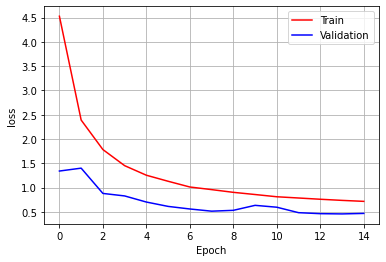

In [ ]:
plt.plot(range(epoch_counter), loss_train_hist, 'r-', label='Train')
plt.plot(range(epoch_counter), loss_valid_hist, 'b-', label='Validation')

plt.xlabel('Epoch')
plt.ylabel('loss')
plt.grid(True)
plt.legend()

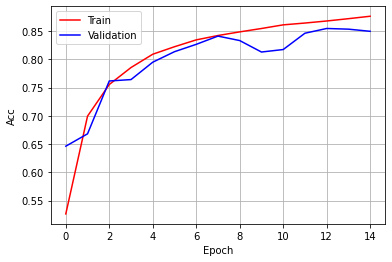

In [ ]:
plt.plot(range(epoch_counter), acc_train_hist, 'r-', label='Train')
plt.plot(range(epoch_counter), acc_valid_hist, 'b-', label='Validation')

plt.xlabel('Epoch')
plt.ylabel('Acc')
plt.grid(True)
plt.legend()

In [ ]:
# Important NOTE 1:
# The train loss should not necessarily go below the valid loss
# In most normal cases (training seperate notworks with no knowledge distilation), eventually, the train loss goes below the valid loss
# Yet, in this case is different
# The train loss is the sum of both losses. Therefore, inherently, it is greater than valid loss
# So, do not be sensitive on this

In [ ]:
# Second important note:
# As can be seen, it is underfit and 15 epcohs were used for testing and education. So, do NOT be senstive on that

In [ ]:
# 3rd important note:
# We could improve the final accuracy by approximately 2% (83 to 85)

In [ ]:
# We should also explore self-distilation

In [ ]:
# Cnotanct: Shayanrokhva1999@gmail.com